# 5 — The Art Gallery Problem: Fisk's proof, implemented and verified

> **How many guards are needed to watch every point of a gallery?**

Chvatal (1975) proved that `floor(n/3)` guards always suffice for a simple
polygon with `n` vertices, and that some polygons need exactly that many.

Fisk's 1978 proof is three lines long and completely constructive — this
notebook implements it and then *verifies* the result independently:

1. **Triangulate** the polygon.
2. **3-colour** the triangulation's vertices. This always works because the dual
   graph is a tree, so a greedy walk never meets a conflict.
3. Every triangle has one vertex of each colour, so the **least frequent colour
   class** covers every triangle. Three disjoint classes over `n` vertices means
   the smallest has at most `floor(n/3)` members. Done.

This connects to my research with the Department of Geometry at the University
of Debrecen on structural and geometric approaches to the problem.

In [1]:
from artgallery import Polygon, triangulate, three_colour, place_guards, verify_coverage

L_SHAPE = [(0, 0), (4, 0), (4, 2), (2, 2), (2, 4), (0, 4)]
poly = Polygon.from_list(L_SHAPE)

print(f"vertices      : {poly.n}")
print(f"area          : {poly.area}")
print(f"convex?       : {poly.is_convex}")
print(f"reflex corners: {[poly.vertices[i] for i in poly.reflex_vertices()]}")
print(f"bound floor(n/3): {poly.theoretical_bound}")

vertices      : 6
area          : 12.0
convex?       : False
reflex corners: [(2.0, 2.0)]
bound floor(n/3): 2


## Step 1 — Triangulation by ear clipping

A vertex is an **ear tip** when it is convex and the triangle formed with its
neighbours contains no other vertex. The Two Ears Theorem guarantees every
simple polygon with more than three vertices has at least two, so clipping
always terminates.

A correct triangulation of an `n`-gon has exactly `n - 2` triangles whose areas
sum to the polygon's area — both are asserted in the test suite, and the area
check is the strong one: it fails if any triangle strays outside the boundary
or if two overlap.

In [2]:
from artgallery import polygon_area

triangles = triangulate(poly)
print(f"{len(triangles)} triangles (expected n - 2 = {poly.n - 2})")

total = sum(abs(polygon_area([poly.vertices[i] for i in t])) for t in triangles)
print(f"triangle area sum: {total}  vs polygon area: {poly.area}")

4 triangles (expected n - 2 = 4)
triangle area sum: 12.0  vs polygon area: 12.0


## Step 2 — Three-colouring

Walk the dual graph breadth-first. Each new triangle shares an edge — two
already-coloured vertices — with its parent, so the third vertex has exactly one
colour left. No backtracking, no conflict.

In [3]:
colouring = three_colour(triangles)
for t in triangles:
    print(f"triangle {t} -> colours {[colouring[v] for v in t]}")

assert all(len({colouring[v] for v in t}) == 3 for t in triangles)
print("\nEvery triangle is tri-chromatic.")

triangle (0, 1, 2) -> colours [0, 1, 2]
triangle (0, 2, 3) -> colours [0, 2, 1]
triangle (5, 0, 3) -> colours [2, 0, 1]
triangle (3, 4, 5) -> colours [1, 0, 2]

Every triangle is tri-chromatic.


## Step 3 — Guards on the smallest colour class

In [4]:
from collections import Counter

solution = place_guards(poly)
print("colour class sizes:", dict(Counter(colouring.values())))
print(f"guards placed on colour {solution.guard_colour}: {solution.guard_points}")
print()
print(solution.summary())
print(f"coverage verified: {verify_coverage(solution)}")

colour class sizes: {0: 2, 1: 2, 2: 2}
guards placed on colour 0: [(0.0, 0.0), (2.0, 4.0)]

n=6 vertices, 1 reflex  |  4 triangles  |  2 guards (bound floor(n/3) = 2)
coverage verified: True


## Drawing it

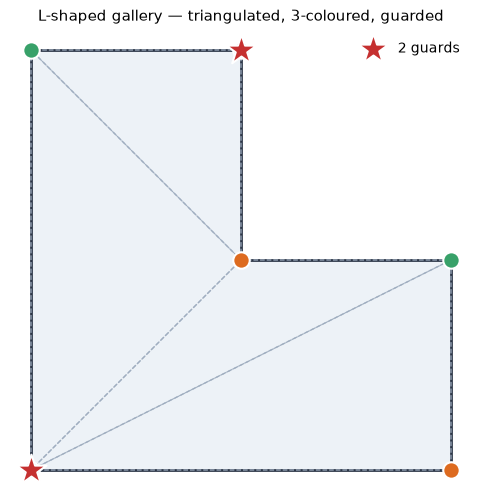

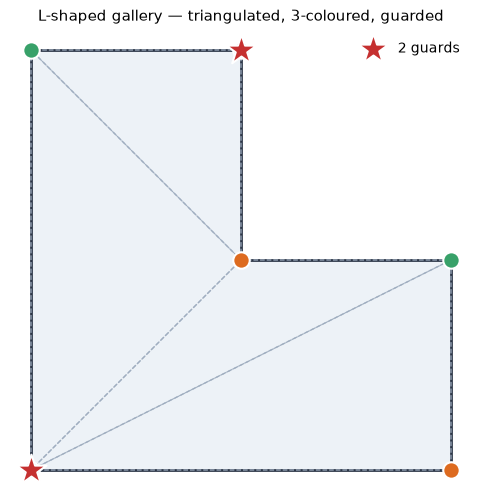

In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon

def draw(solution, title=""):
    poly = solution.polygon
    fig, ax = plt.subplots(figsize=(7, 6))
    verts = list(poly.vertices)

    ax.add_patch(MplPolygon(verts, closed=True, facecolor="#edf2f7",
                            edgecolor="#2d3748", linewidth=2, zorder=1))
    for tri in solution.triangles:
        pts = [poly.vertices[i] for i in tri]
        ax.add_patch(MplPolygon(pts, closed=True, fill=False,
                                edgecolor="#a0aec0", linestyle="--",
                                linewidth=0.9, zorder=2))

    palette = ["#3182ce", "#dd6b20", "#38a169"]
    for i, (x, y) in enumerate(verts):
        ax.scatter(x, y, s=140, color=palette[solution.colouring[i]],
                   edgecolors="white", linewidth=1.5, zorder=3)

    gx = [p[0] for p in solution.guard_points]
    gy = [p[1] for p in solution.guard_points]
    ax.scatter(gx, gy, s=520, marker="*", color="#c53030",
               edgecolors="white", linewidth=1.5, zorder=4,
               label=f"{solution.n_guards} guards")

    ax.set_title(title or solution.summary(), fontsize=11)
    ax.legend(frameon=False)
    ax.set_aspect("equal")
    ax.axis("off")
    return fig

draw(solution, "L-shaped gallery — triangulated, 3-coloured, guarded")

## The tight case: the comb

Sufficiency is only half the theorem. The **comb** shows `floor(n/3)` guards are
sometimes *necessary*: each prong's tip is visible only from inside that prong,
so no single guard can cover two of them.

n=17 vertices, 8 reflex  |  15 triangles  |  5 guards (bound floor(n/3) = 5)


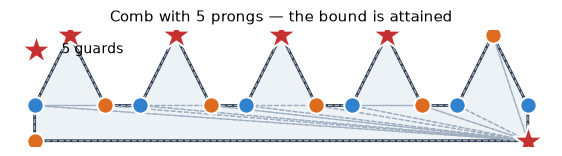

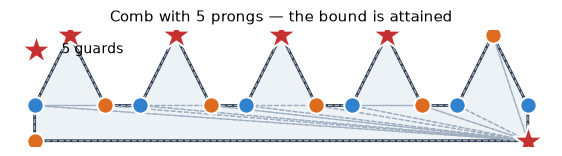

In [6]:
def comb(teeth):
    pts = []
    for i in range(teeth):
        x = 3.0 * i
        pts += [(x, 0.0), (x + 1.0, 2.0), (x + 2.0, 0.0)]
    pts.append((3.0 * teeth - 1.0, -1.0))
    pts.append((0.0, -1.0))
    return pts

comb_solution = place_guards(Polygon.from_list(comb(5)))
print(comb_solution.summary())
draw(comb_solution, "Comb with 5 prongs — the bound is attained")

## Scaling behaviour

For the comb family the solver hits the bound exactly. For most polygons it uses
fewer guards, because `floor(n/3)` is a worst case, not a target.

In [7]:
import pandas as pd

rows = []
for teeth in range(2, 11):
    p = Polygon.from_list(comb(teeth))
    s = place_guards(p)
    rows.append({"prongs": teeth, "n": p.n, "reflex": len(p.reflex_vertices()),
                 "triangles": len(s.triangles), "guards": s.n_guards,
                 "floor(n/3)": p.theoretical_bound})
pd.DataFrame(rows)

,prongs,n,reflex,triangles,guards,floor(n/3)
0,2,8,2,6,2,2
1,3,11,4,9,3,3
2,4,14,6,12,4,4
3,5,17,8,15,5,5
4,6,20,10,18,6,6
5,7,23,12,21,7,7
6,8,26,14,24,8,8
7,9,29,16,27,9,9
8,10,32,18,30,10,10


In [8]:
# A convex polygon needs exactly one guard, whatever n is: any single vertex
# sees the entire interior.
import math
hexagon = [(math.cos(2 * math.pi * i / 6), math.sin(2 * math.pi * i / 6)) for i in range(6)]
print(place_guards(Polygon.from_list(hexagon)).summary())

n=6 vertices, 0 reflex  |  4 triangles  |  1 guards (bound floor(n/3) = 2)


## Where this goes next

`floor(n/3)` is a bound, not an optimum. Finding the **minimum** guard set for a
given polygon is NP-hard (Lee & Lin, 1986), and the gap between the bound and
the true optimum is where the research sits:

- **Reflex vertices**, not `n`, are what make an instance hard — a convex
  polygon of any size needs one guard.
- Restricted classes (orthogonal polygons: `floor(n/4)`) admit tighter bounds.
- Variants: guards restricted to edges, mobile guards patrolling a segment,
  polygons with holes.

The connection to the risk work elsewhere in this repository is genuine but
structural rather than financial: both are **covering problems on a graph** —
place the fewest monitors so that every region is observed. It would be
dishonest to claim more than that.